# 🎤 Speech Emotion Recognition using Deep Learning

## CodeAlpha Machine Learning Internship

### Project Overview

Speech Emotion Recognition (SER) is the task of identifying human emotions from speech audio using machine learning and deep learning techniques.

In this project, audio recordings will be processed to extract meaningful acoustic features such as Mel-Frequency Cepstral Coefficients (MFCCs). A deep learning model will then classify speech into different emotional categories.

The project follows a complete machine learning workflow including:

- Dataset Exploration
- Audio Preprocessing
- Feature Extraction
- Deep Learning Model Development
- Model Evaluation
- Streamlit Deployment

# Project Objectives

The objectives of this project are:

- Understand the Speech Emotion Recognition problem.
- Explore the RAVDESS speech dataset.
- Perform audio preprocessing.
- Extract MFCC features from speech signals.
- Train a deep learning model for emotion classification.
- Evaluate model performance using standard metrics.
- Save the trained model.
- Build a Streamlit application for emotion prediction.

# Technologies Used

- Python
- TensorFlow / Keras
- Librosa
- NumPy
- Pandas
- Matplotlib
- Seaborn
- Scikit-learn
- Streamlit

# Table of Contents

1. Import Libraries
2. Dataset Loading
3. Dataset Exploration
4. Audio Visualization
5. Audio Preprocessing
6. MFCC Feature Extraction
7. Dataset Preparation
8. CNN Model Development
9. Model Training
10. Model Evaluation
11. Save Model
12. Streamlit Deployment
13. Conclusion

# Import Libraries

In [2]:
# File Handling
import os

# Numerical Computing
import numpy as np

# Data Handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Audio Processing
import librosa
import librosa.display

# Machine Learning Utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Conv1D,
    MaxPooling1D,
    Dropout,
    Flatten,
    BatchNormalization
)
from tensorflow.keras.utils import to_categorical

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Dataset Loading

The RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song) dataset contains speech recordings from multiple actors expressing different emotions.

Unlike traditional machine learning datasets that are stored as CSV files, this dataset consists of audio files organized into folders. Therefore, the first step is to scan the dataset directory, read each audio file, extract its corresponding emotion label from the filename, and organize the information into a structured pandas DataFrame for further analysis.

In [3]:
emotion_map = {
    "01": "Neutral",
    "02": "Calm",
    "03": "Happy",
    "04": "Sad",
    "05": "Angry",
    "06": "Fearful",
    "07": "Disgust",
    "08": "Surprised"
}

In [4]:
file_paths = []
emotions = []
actors = []

In [5]:
dataset_path = "dataset"

print("Dataset exists:", os.path.exists(dataset_path))

Dataset exists: True


In [6]:
dataset_path = "dataset"

for actor in os.listdir(dataset_path):

    actor_path = os.path.join(dataset_path, actor)

    if os.path.isdir(actor_path):

        for file in os.listdir(actor_path):

            if file.endswith(".wav"):

                parts = file.split("-")

                emotion_code = parts[2]

                actor_id = parts[-1].replace(".wav", "")

                file_paths.append(os.path.join(actor_path, file))

                emotions.append(emotion_map[emotion_code])

                actors.append(actor_id)

In [7]:
df = pd.DataFrame({
    "File_Path": file_paths,
    "Emotion": emotions,
    "Actor": actors
})

In [8]:
df.head()

,File_Path,Emotion,Actor
0,dataset\Actor_01\03-01-01-01-01-01-01.wav,Neutral,01
1,dataset\Actor_01\03-01-01-01-01-02-01.wav,Neutral,01
2,dataset\Actor_01\03-01-01-01-02-01-01.wav,Neutral,01
3,dataset\Actor_01\03-01-01-01-02-02-01.wav,Neutral,01
4,dataset\Actor_01\03-01-02-01-01-01-01.wav,Calm,01


In [9]:
print(df.shape)

(1440, 3)


In [10]:
df["Emotion"].value_counts()

Emotion
Calm         192
Happy        192
Sad          192
Angry        192
Fearful      192
Disgust      192
Surprised    192
Neutral       96
Name: count, dtype: int64

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to better understand the structure and characteristics of the Speech Emotion Recognition dataset before training a deep learning model.

The objectives of this section are to:

- Understand the distribution of emotion classes.
- Verify that the dataset is balanced.
- Check for missing or duplicate records.
- Explore the actor distribution.
- Inspect sample audio recordings before feature extraction.

Performing EDA helps identify potential issues in the dataset and provides insights that guide preprocessing and model development.

In [11]:
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

Dataset Shape: (1440, 3)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 1440 entries, 0 to 1439
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   File_Path  1440 non-null   str  
 1   Emotion    1440 non-null   str  
 2   Actor      1440 non-null   str  
dtypes: str(3)
memory usage: 102.5 KB


In [12]:
df.describe(include="object")

,File_Path,Emotion,Actor
count,1440,1440,1440
unique,1440,8,24
top,dataset\Actor_01\03-01-01-01-01-01-01.wav,Calm,01
freq,1,192,60


In [13]:
df.isnull().sum()

File_Path    0
Emotion      0
Actor        0
dtype: int64

In [14]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


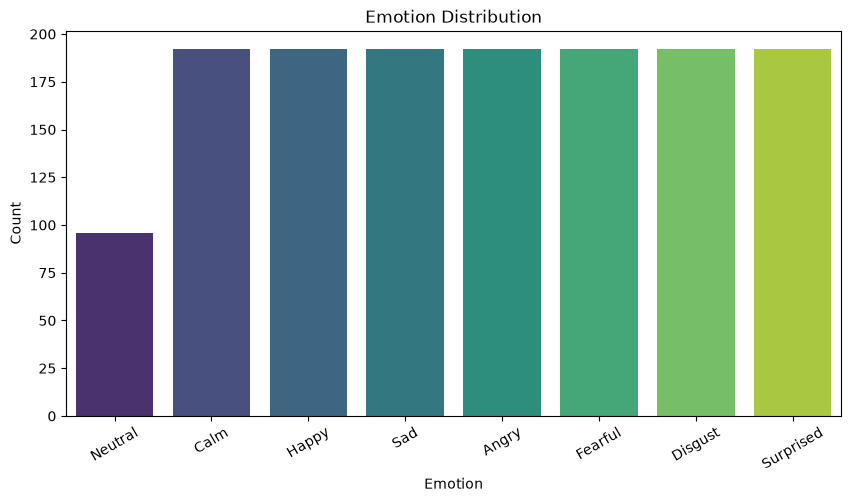

In [15]:
plt.figure(figsize=(10,5))

sns.countplot(
    data=df,
    x="Emotion",
    hue="Emotion",
    palette="viridis",
    legend=False
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Count")

plt.xticks(rotation=30)

plt.show()

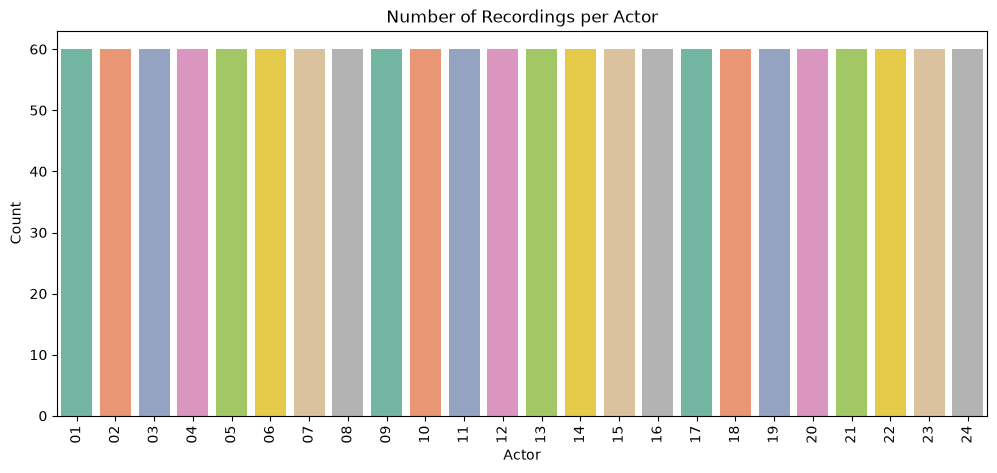

In [16]:
plt.figure(figsize=(12,5))

sns.countplot(
    data=df,
    x="Actor",
    hue="Actor",
    palette="Set2",
    legend=False
)

plt.title("Number of Recordings per Actor")
plt.xlabel("Actor")
plt.ylabel("Count")

plt.xticks(rotation=90)

plt.show()

In [17]:
sample_audio = df.iloc[0]["File_Path"]

print(sample_audio)

dataset\Actor_01\03-01-01-01-01-01-01.wav


In [18]:
signal, sample_rate = librosa.load(
    sample_audio,
    sr=None
)

In [19]:
print("Signal Shape:", signal.shape)

print("Sample Rate:", sample_rate)

Signal Shape: (158558,)
Sample Rate: 48000


# MFCC Feature Extraction

Raw audio signals contain thousands of amplitude values that are difficult for machine learning models to interpret directly.

To obtain meaningful information from speech recordings, Mel-Frequency Cepstral Coefficients (MFCCs) are extracted. MFCCs provide a compact representation of speech characteristics by emphasizing frequencies that are important to human hearing.

These extracted features will be used as input to the deep learning model for emotion classification.

# Audio Signal Visualization

Before extracting numerical features from the speech recordings, it is important to understand the structure of the raw audio signal.

An audio recording is represented as a sequence of amplitude values sampled over time. By visualizing the waveform, we can observe how the sound intensity changes throughout the recording.

In this section, we will:

- Load a sample audio recording.
- Visualize its waveform.
- Understand the sampling rate and signal length.
- Prepare the audio for feature extraction in the next stage.

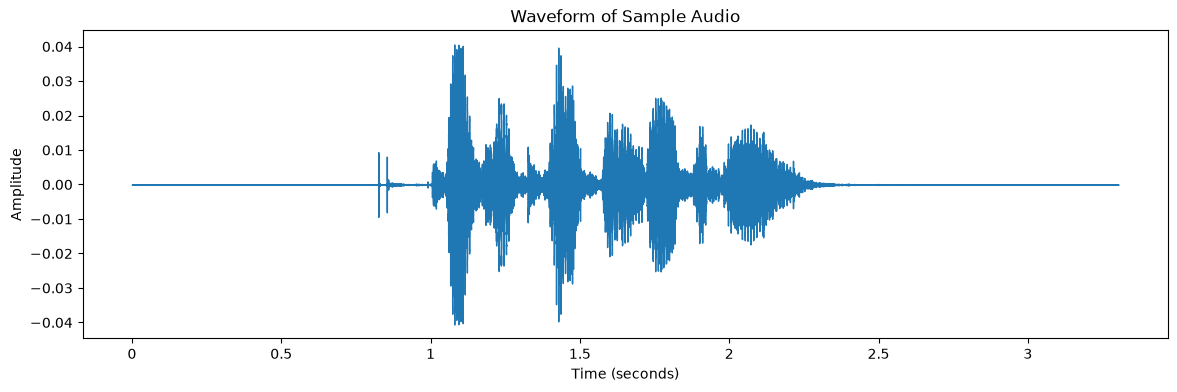

In [20]:
plt.figure(figsize=(14,4))

librosa.display.waveshow(
    signal,
    sr=sample_rate
)

plt.title("Waveform of Sample Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

# Spectrogram Visualization

While the waveform shows how the audio changes over time, it does not reveal which frequencies are present.

A spectrogram is a visual representation of the frequencies contained in an audio signal over time. It provides a richer understanding of speech patterns and is widely used in speech processing applications.

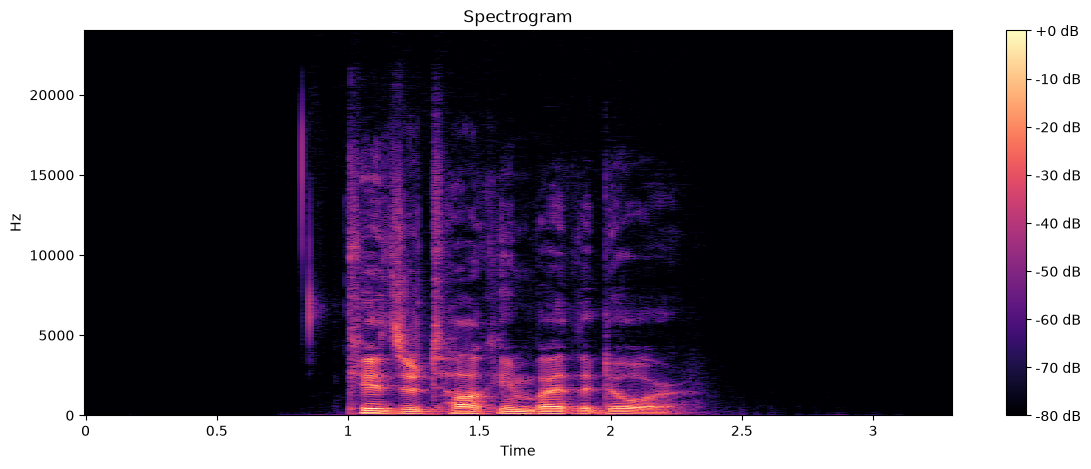

In [21]:
D = librosa.amplitude_to_db(
    np.abs(librosa.stft(signal)),
    ref=np.max
)

plt.figure(figsize=(14,5))

librosa.display.specshow(
    D,
    sr=sample_rate,
    x_axis="time",
    y_axis="hz"
)

plt.colorbar(format="%+2.0f dB")

plt.title("Spectrogram")

plt.show()

# Mel-Frequency Cepstral Coefficients (MFCC)

Raw audio signals contain thousands of amplitude values that are difficult for machine learning models to interpret directly.

To obtain meaningful features from speech recordings, Mel-Frequency Cepstral Coefficients (MFCCs) are extracted. MFCCs provide a compact numerical representation of speech by emphasizing frequency characteristics that closely match human hearing.

These features will be used as the input to the deep learning model for emotion classification.

In [22]:
mfcc = librosa.feature.mfcc(
    y=signal,
    sr=sample_rate,
    n_mfcc=40
)

print("MFCC Shape:", mfcc.shape)

MFCC Shape: (40, 310)


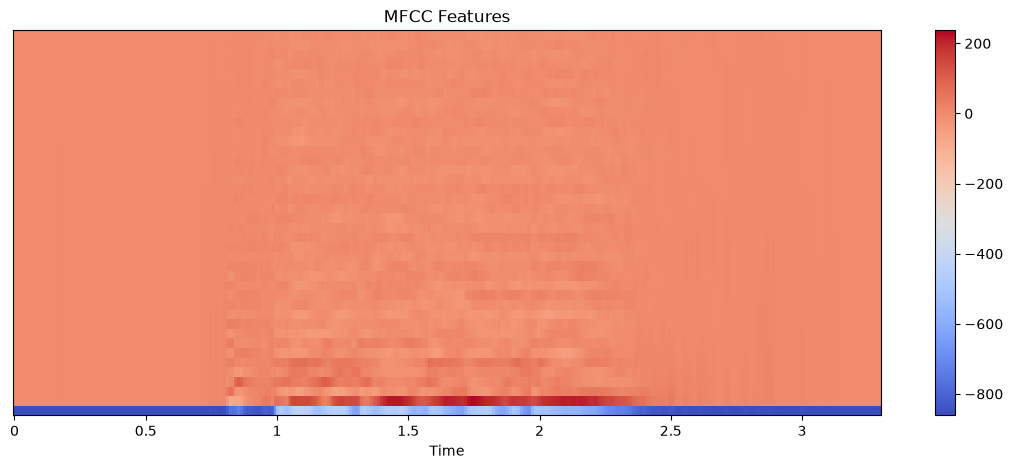

In [23]:
plt.figure(figsize=(14,5))

librosa.display.specshow(
    mfcc,
    x_axis="time",
    sr=sample_rate
)

plt.colorbar()

plt.title("MFCC Features")

plt.show()

# Feature Extraction

Deep learning models require numerical feature vectors as input. Instead of using raw audio signals directly, MFCC features are extracted from every speech recording in the dataset.

For each audio file:

- The audio is loaded.
- Forty MFCC coefficients are extracted.
- The mean of each coefficient is calculated.
- The resulting feature vector represents one speech recording.

Finally, all feature vectors are combined into a feature matrix for model training.

In [24]:
def extract_features(file_path):

    signal, sample_rate = librosa.load(
        file_path,
        sr=None
    )

    mfcc = librosa.feature.mfcc(
        y=signal,
        sr=sample_rate,
        n_mfcc=40
    )

    mfcc = np.mean(mfcc.T, axis=0)

    return mfcc

In [25]:
X = []
y = []

for index, row in df.iterrows():

    features = extract_features(row["File_Path"])

    X.append(features)

    y.append(row["Emotion"])

In [26]:
X = np.array(X)
y = np.array(y)

print("Feature Matrix Shape:", X.shape)
print("Labels Shape:", y.shape)

Feature Matrix Shape: (1440, 40)
Labels Shape: (1440,)


# Data Preparation

Before training the neural network, the extracted features and emotion labels must be prepared.

The feature matrix is normalized to ensure that all input features have a similar scale. The emotion labels are encoded into numerical values and then converted into one-hot encoded vectors, which are required for multi-class classification.

Finally, the dataset is divided into training and testing sets to evaluate the performance of the model on unseen data.

In [27]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = scaler.fit_transform(X)

In [28]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print(label_encoder.classes_)

['Angry' 'Calm' 'Disgust' 'Fearful' 'Happy' 'Neutral' 'Sad' 'Surprised']


In [29]:
y = to_categorical(y_encoded)

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [31]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (1152, 40)
Testing Features: (288, 40)
Training Labels: (1152, 8)
Testing Labels: (288, 8)


# Deep Neural Network Model

A Deep Neural Network (DNN) is used to classify speech recordings into eight different emotion categories.

The network consists of multiple fully connected (Dense) layers with ReLU activation functions. Dropout layers are included to reduce overfitting by randomly disabling neurons during training.

The final output layer uses the Softmax activation function to produce probability scores for each emotion class.

In [32]:
model = Sequential([
    
    Dense(128, activation="relu", input_shape=(40,)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(8, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           264 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,848 (61.91 KB)

 Trainable params: 15,848 (61.91 KB)

 Non-trainable params: 0 (0.00 B)

# Model Compilation

Before training, the neural network must be compiled by specifying three important components:

- **Optimizer:** Updates the model's weights during training. The Adam optimizer is selected because it provides efficient and stable learning.
- **Loss Function:** Measures the difference between the predicted and actual emotion labels. Since this is a multi-class classification problem, Categorical Crossentropy is used.
- **Evaluation Metric:** Accuracy is used to measure the percentage of correctly classified speech samples during training and testing.

In [34]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Model Training

The neural network is trained using the prepared training dataset.

During training, the model repeatedly processes the training data over multiple epochs. After each epoch, the model updates its internal weights to reduce prediction errors.

A validation split is used to monitor the model's performance on unseen training data and detect potential overfitting.

In [35]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.1401 - loss: 2.1187 - val_accuracy: 0.1602 - val_loss: 2.0303
Epoch 2/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2009 - loss: 1.9999 - val_accuracy: 0.2035 - val_loss: 1.9830
Epoch 3/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.2519 - loss: 1.9254 - val_accuracy: 0.2944 - val_loss: 1.8976
Epoch 4/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.2790 - loss: 1.8817 - val_accuracy: 0.3247 - val_loss: 1.8316
Epoch 5/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3322 - loss: 1.7906 - val_accuracy: 0.3160 - val_loss: 1.7704
Epoch 6/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3333 - loss: 1.7351 - val_accuracy: 0.3723 - val_loss: 1.7082
Epoch 7/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3898 - loss: 1.6453 - val_accuracy: 0.3723 - val_loss: 1.6707
Epoch 8/50
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3985 - loss: 1.5936 - val_accuracy: 0.3810 - v

# Model Evaluation

After training, the model is evaluated using the testing dataset to measure its ability to classify unseen speech recordings.

Several evaluation metrics are used, including:

- Test Accuracy
- Classification Report
- Confusion Matrix

These metrics provide insights into the strengths and weaknesses of the trained model for each emotion category.

In [36]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.5833
Test Loss: 1.2337


In [37]:
y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step  


In [38]:
print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

       Angry       0.81      0.76      0.78        38
        Calm       0.62      0.68      0.65        38
     Disgust       0.56      0.53      0.54        38
     Fearful       0.53      0.74      0.62        39
       Happy       0.51      0.54      0.53        39
     Neutral       0.35      0.32      0.33        19
         Sad       0.58      0.50      0.54        38
   Surprised       0.64      0.46      0.54        39

    accuracy                           0.58       288
   macro avg       0.57      0.57      0.57       288
weighted avg       0.59      0.58      0.58       288



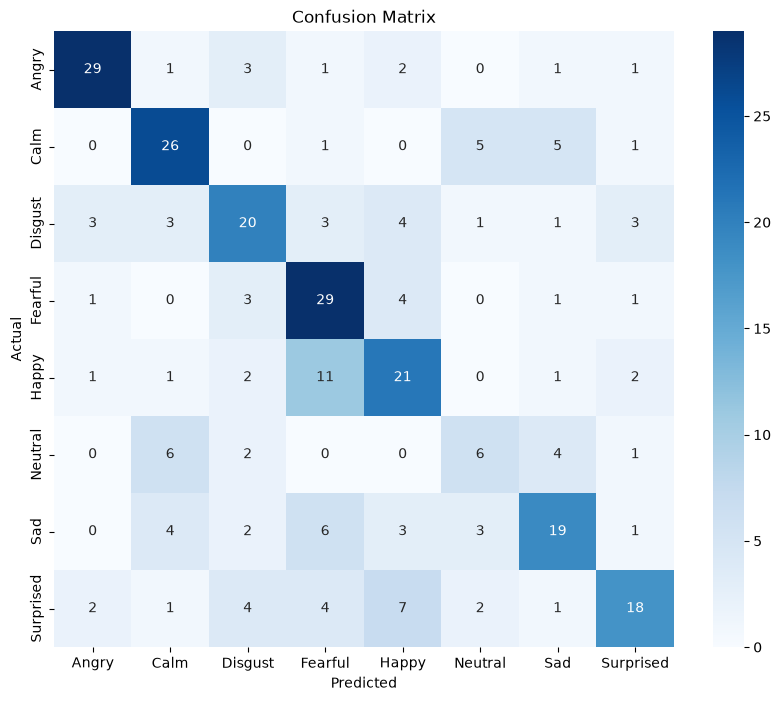

In [39]:
cm = confusion_matrix(
    y_true,
    y_pred_classes
)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()